In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils

from statsmodels.tsa.arima.model import ARIMA
from external.api_repo.generators import *
from external.api_repo.utils import *

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
boltzman= 1.38e-11
zeta = 2.24e-9

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 15
time_step = 4e-3

barrier_height=0.9e-8
left_well=3
right_well=-3
x0_mean=0
tilt=0#1e-12#2e-50


x,dwt=double_wells_generator(total_time=total_time, zeta=zeta,T=T,time_step=time_step,boltzmann=boltzman,right_well=right_well,left_well=left_well,
                          barrier_height=barrier_height,x0_mean=x0_mean,device=device  ,num_of_simulations=8,tilt=tilt)


In [14]:
x_single = x[0]
series = pd.Series(x_single.detach().cpu().numpy())

model = ARIMA(series, order=(1, 0, 1))
result = model.fit()

In [15]:
#print(result.summary())

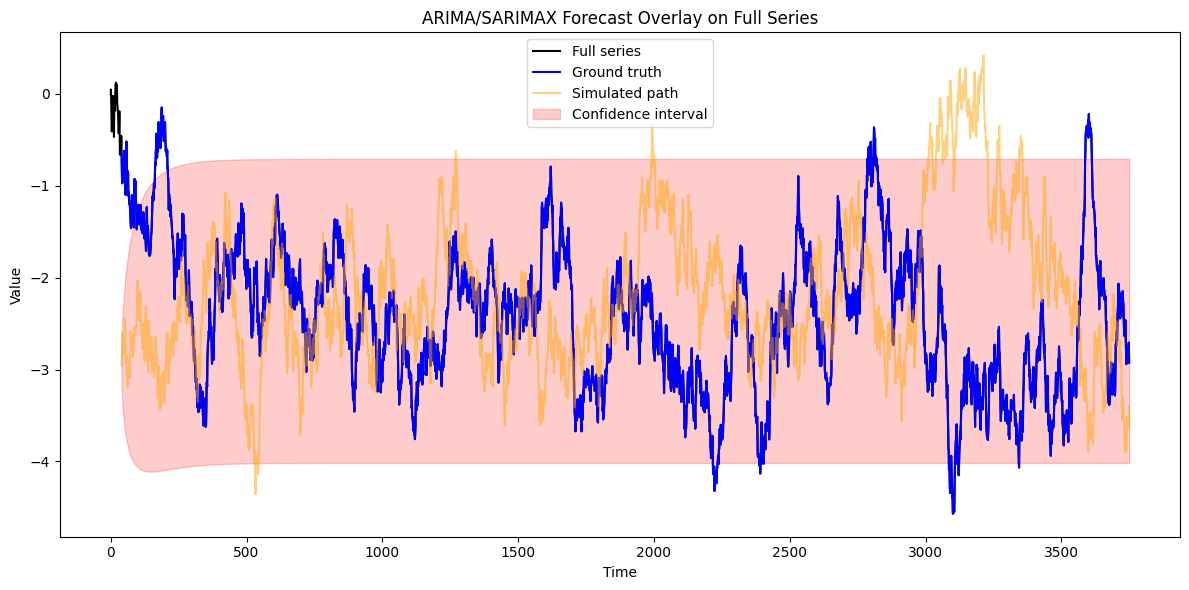

In [ ]:
utils.plot_arima_simulated_forecast(series, result,t=1000)